In [1]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from accelerate import Accelerator
import random
import urllib.request
import tarfile

BATCH_SIZE = 32
LR = 5e-6
EPOCHS = 5
DATA_DIR = "./CUB_200_2011"
BASE_MODEL = "openai/clip-vit-base-patch32"

accelerator = Accelerator(mixed_precision="fp16")
device = accelerator.device

## Parsing the Dataset

I begin by parsing the `CUB_200_2011` dataset merging the images paths,labels, 
class and attributes which are spread across multiple files into a single data 
frame. I uses this data to create a prompt using this data which is processed to 
into an initial embedding for training.

In [2]:
os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(os.path.join(DATA_DIR, "CUB_200_2011/images.txt")):
    print("Downloading dataset...")
    tar_path = "./CUB_200_2011.tgz"
    urllib.request.urlretrieve(
        "https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz?download=1",
        tar_path,
    )
    print("Extracting dataset...")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(DATA_DIR)
    os.remove(tar_path)
    print("Dataset ready!")
else:
    print("Dataset already available.")


Dataset already available.


In [3]:
prompt_templates = [
    "a photo of a {class_name} with {attrs}",
    "{class_name} with {attrs}",
    "a {class_name}, has {attrs}",
    "{class_name}, {attrs}",
]

class BirdDataset(Dataset):


    def __init__(self, root, processor, split=None):
        self.root = root
        self.processor = processor

        # Images
        images = pd.read_csv(
            os.path.join(self.root, "CUB_200_2011/images.txt"),
            sep=r"\s+",
            names=["id", "path"],
        )

        # Labels
        labels = pd.read_csv(
            os.path.join(self.root, "CUB_200_2011/image_class_labels.txt"),
            sep=r"\s+",
            names=["id", "class_id"],
        )

        # Classes
        classes = pd.read_csv(
            os.path.join(self.root, "CUB_200_2011/classes.txt"),
            sep=r"\s+",
            names=["class_id", "class_name"],
        )
        classes["class_name"] = (
            classes["class_name"].str.split(".").str[1].str.replace("_", " ")
        )

        # Attributes
        attr_names_path = os.path.join(self.root, "attributes.txt")
        attr_names = pd.read_csv(
            attr_names_path, sep=r"\s+", names=["attr_id", "attr_name"]
        )
        attr_names["attr_name"] = (
            attr_names["attr_name"]
            .str.replace("has_", "")
            .str.replace("::", " ")
            .str.replace("_", " ")
        )
        attr_map_path = os.path.join(
            self.root, "CUB_200_2011/attributes/image_attribute_labels.txt"
        )
        attr_map = pd.read_csv(
            attr_map_path,
            sep=r"\s+",
            names=["id", "attr_id", "is_present", "certainty", "time"],
            usecols=[0, 1, 2],
        )
        attr_present = attr_map[attr_map["is_present"] == 1]
        attr_joined = attr_present.merge(attr_names, on="attr_id")
        self.image_to_attrs = (
            attr_joined.groupby("id")["attr_name"]
            # Randomize attribute order for better queries
            .apply(lambda x: ", ".join(random.sample(list(x), min(random.randint(6, 12), len(x)))))
            .reset_index()
        )

        # Merge everything into a final data frame
        self.df = images.merge(labels, on="id").merge(classes, on="class_id")
        self.df = self.df.merge(self.image_to_attrs, on="id", how="left")
        self.df["attr_name"] = self.df["attr_name"].fillna("bird features")

        # If specified only load the data specified as either train or test data
        if split is not None:
            split_df = pd.read_csv(
                os.path.join(self.root, "CUB_200_2011/train_test_split.txt"),
                sep=r"\s+",
                names=["id", "is_train"],
            )
            self.df = self.df.merge(split_df, on="id")
            if split == "train":
                self.df = self.df[self.df["is_train"] == 1]
            else:
                self.df = self.df[self.df["is_train"] == 0]

        self.df = self.df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root, "CUB_200_2011/images", row["path"])
        image = Image.open(img_path).convert("RGB")

        # This line creates the final prompt that will be used to train the clip 
        # model
        text = random.choice(prompt_templates).format(class_name=row["class_name"], attrs=row["attr_name"])

        inputs = self.processor(
            text=[text],
            images=image,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=77,
        )

        return {
            "pixel_values": inputs["pixel_values"].squeeze(0),
            "input_ids": inputs["input_ids"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "path": row["path"],
            "class_id": row["class_id"],
            "class_name": row["class_name"],
            "attr_name": row["attr_name"],
        }



The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Train samples: 5994, Test samples: 5794
Random Training Samples:

Sample 1:
  Class: Yellow Warbler
  Attributes: leg color buff, forehead color grey, crown color yellow, primary color yellow, back color grey, breast color grey, size small (5 - 9 in)
  Prompt: Yellow Warbler with leg color buff, forehead color grey, crown color yellow, primary color yellow, back color grey, breast color grey, size small (5 - 9 in)

Sample 2:
  Class: Least Tern
  Attributes: wing pattern solid, tail pattern solid, wing shape tapered-wings, bill color black, wing color grey, upperparts color grey, primary color grey, bill length longer than head
  Prompt: a photo of a Least Tern with wing pattern solid, tail pattern solid, wing shape tapered-wings, bill color black, wing color grey, upperparts color grey, primary color grey, bill length longer than head

Sample 3:
  Class: Heermann Gull
  Attributes: tail pattern multi-colored, nape color white, wing pattern solid, eye color grey, bill color orange, upp

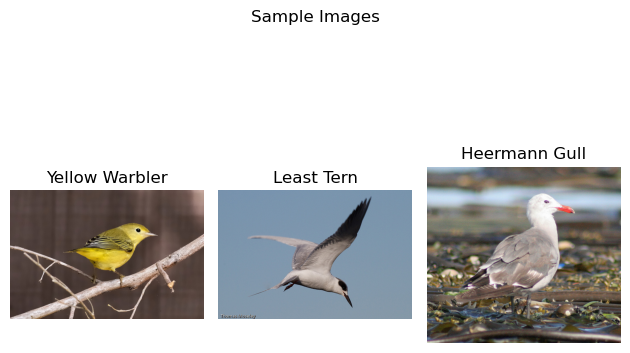

In [4]:
IMAGES_DIR = "./CUB_200_2011/CUB_200_2011/images"

processor = CLIPProcessor.from_pretrained(BASE_MODEL)
train_dataset = BirdDataset(DATA_DIR, processor, split="train")
test_dataset = BirdDataset(DATA_DIR, processor, split="test")
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

# Get random samples
sample_indices = [random.randint(0, len(train_dataset) - 1) for _ in range(3)]

# Print Sample attributes and matching image
print("Random Training Samples:\n")
for i, idx in enumerate(sample_indices):
    sample = train_dataset[idx]
    prompt = random.choice(prompt_templates).format(class_name=sample['class_name'], attrs=sample['attr_name'])
    print(f"Sample {i+1}:")
    print(f"  Class: {sample['class_name']}")
    print(f"  Attributes: {sample['attr_name']}")
    print(f"  Prompt: {prompt}")
    print()

fig, axes = plt.subplots(1, 3)
fig.suptitle("Sample Images")
for col, idx in enumerate(sample_indices):
    sample = train_dataset[idx]
    img_path = os.path.join(IMAGES_DIR, sample['path'])
    img = Image.open(img_path)
    ax = axes[col]
    ax.imshow(img)
    ax.set_title(f"{sample['class_name']}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## Fine Tune Clip Model

Secondly I fine tune the model using `openai/clip-vit-base-patch32` as the base model. 
I achieve this using the prompts that were generated and processed in the previous 
step with the attributes from dataset and the processed image data. 

In [5]:
model = CLIPModel.from_pretrained(BASE_MODEL)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

model, optimizer, train_loader = accelerator.prepare(model, optimizer, train_loader)

for epoch in range(EPOCHS):
    model.train()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}")
    for batch in pbar:
        optimizer.zero_grad()

        outputs = model(
            pixel_values=batch["pixel_values"],
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            return_loss=True,
        )

        loss = outputs.loss
        accelerator.backward(loss)
        optimizer.step()

        pbar.set_postfix({"loss": loss.item()})

# Save the final weights for use in the 
unwrapped_model = accelerator.unwrap_model(model)
unwrapped_model.save_pretrained("bird_clip_model")
print("Saved Fine tuned weights")

# Split the model file into chunks under 100MB for GitHub
model_file = "bird_clip_model/model.safetensors"
if os.path.exists(model_file):
    chunk_size = 40 * 1024 * 1024  # 90MB
    with open(model_file, "rb") as f:
        part_num = 0
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            with open(f"bird_clip_model/model_part_{chr(97 + part_num)}", "wb") as out:
                out.write(chunk)
            part_num += 1
    os.remove(model_file)
    print(f"Split model into {part_num} chunks")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 5: 100%|██████████| 188/188 [00:49<00:00,  3.76it/s, loss=0.0169]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved Fine tuned weights
Split model into 15 chunks


## Results

Finally using the fine-tuned model I generate an embedding for each of the images 
in the test dataset. Which is these embeddings are used to calculate the cosine 
similarity between the embedding of the users query and each images. which can 
then be used to rank the images based on how similar they are to the query.

In [6]:
model.eval()
all_embeddings = []
all_paths = []

eval_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

with torch.no_grad():
    # Generate an embedding for each of the images in the test_dataset
    for batch in tqdm(eval_loader):
        img_features = model.get_image_features(
            pixel_values=batch["pixel_values"].to(device)
        ).pooler_output
        img_features /= img_features.norm(dim=-1, keepdim=True)
        all_embeddings.append(img_features.cpu())
        all_paths.extend(batch["path"])

# Save a mapping from embedding to original image path
index_data = {"embeddings": torch.cat(all_embeddings), "paths": all_paths}
torch.save(index_data, "bird_index.pt")

100%|██████████| 182/182 [01:16<00:00,  2.39it/s]


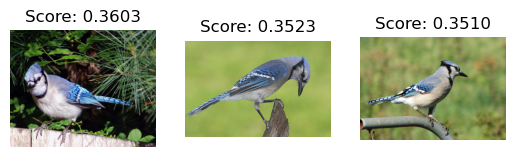

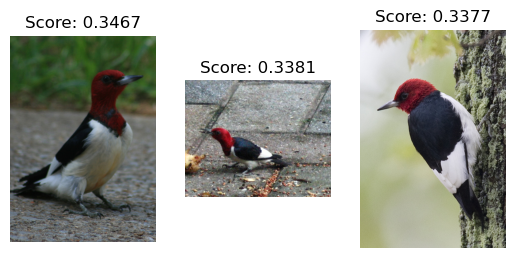

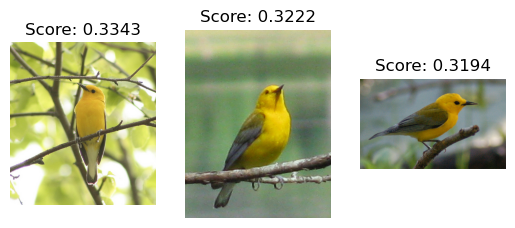

In [7]:
def search(query, top=3):
    # Encoder query into embedding space
    inputs = processor(text=[query], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_features = model.get_text_features(**inputs).pooler_output
        text_features /= text_features.norm(dim=-1, keepdim=True)

    # Compute the cosine similarity between the query embedding and the image embeddings
    index = torch.load("bird_index.pt")
    similarities = (text_features.cpu() @ index["embeddings"].T).squeeze(0)
    values, indices = similarities.topk(top)

    # Plot the top n results
    for i, idx in enumerate(indices):
        img = Image.open(
            os.path.join(DATA_DIR, "CUB_200_2011/images", index["paths"][idx])
        )
        plt.subplot(1, top, i + 1)
        plt.imshow(img)
        plt.title(f"Score: {values[i].item():.4f}")
        plt.axis("off")
    plt.show()


search("a blue jay")
search("a bird with a red head black body and white under parts")
search("a yellow bird with grey wings")
